In [1]:
# Install the required libraries
# #SAM
# !pip install git+https://github.com/facebookresearch/segment-anything.git
# #Transformers
# !pip install -q git+https://github.com/huggingface/transformers.git
#Datasets to prepare data and monai if you want to use special loss functions
!pip install datasets
!pip install -q monai
#Patchify to divide large images into smaller patches for training. (Not necessary for smaller images)
!pip install patchify

In [2]:
%pip install tifffile scipy nibabel

Note: you may need to restart the kernel to use updated packages.


# Exploring the dataset

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib # read nifti files
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage

## Display the image

In [4]:
nifti_file = nib.load("../Brats_dataset_2024/imagesTr/BraTS-GLI-00000-000_0001.nii.gz")
data = nifti_file.get_fdata()

In [5]:
data.shape # the data is a 3d object

(240, 240, 155)

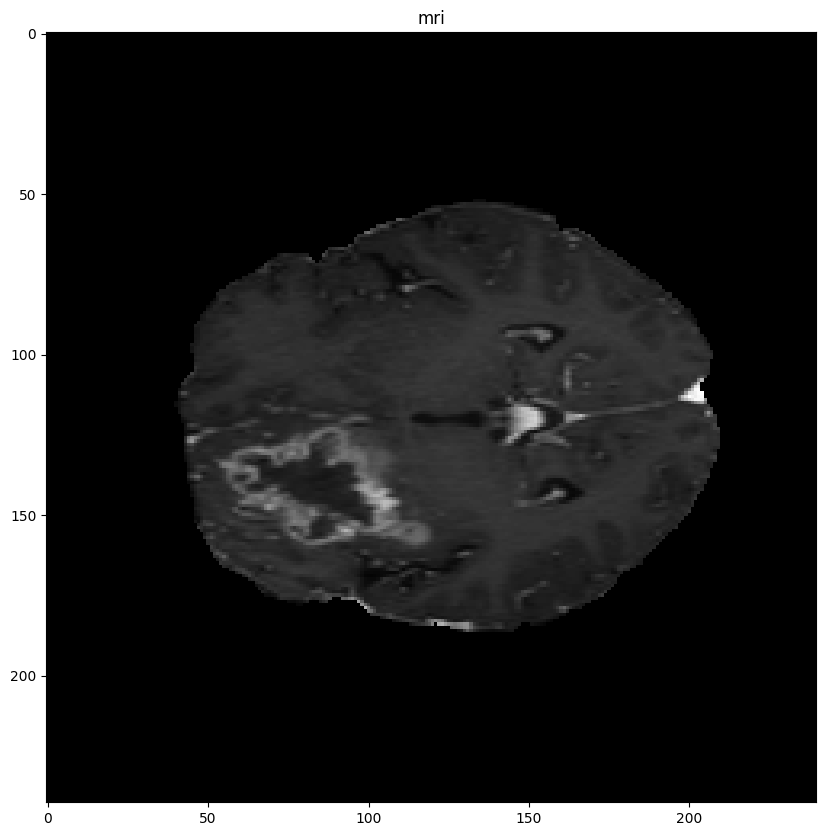

In [6]:

# slice_mid = data.shape[2] // 2.5
plt.figure(figsize=(10,10))
plt.imshow(data[:,:,70],cmap='gray') # we select the slice to display in the nifti object
plt.title('mri')
plt.show()

## Display the label

In [7]:
nifti_label = nib.load("../Brats_dataset_2024/labelsTr/BraTS-GLI-00000-000.nii.gz")
data_label = nifti_label.get_fdata()

In [8]:
data_label.shape # the data is a 3d object

(240, 240, 155)

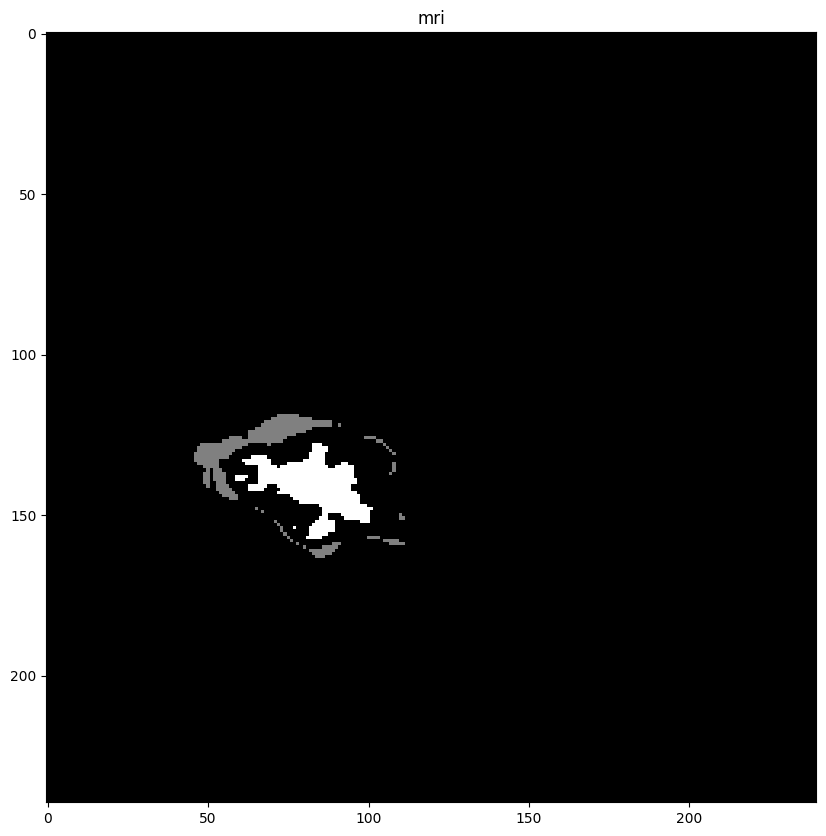

In [9]:

# slice_mid = data.shape[2] // 2.5
plt.figure(figsize=(10,10))
plt.imshow(data_label[:,:,70],cmap='gray') # we select the slice to display in the nifti object
plt.title('mri')
plt.show()

Load data into numpy arrays. Here we are importing a nifti stack containing 155 images of size 240x240, which are layers of the mri of the brain.

In [24]:
#155 large images as nifti image stack in each file

def load_and_transpose_scan(file_path):
    """
Load an NIfTI file and transpose its axes
"""
    img = nib.load(file_path)
    data = img.get_fdata()
    data_transposed = np.transpose(data,(2,0,1))

    return data_transposed, img




In [27]:
imgs_data,stacked_imgs = load_and_transpose_scan(file_path="../Brats_dataset_2024/imagesTr/BraTS-GLI-00000-000_0001.nii.gz")
masks_data,_ = load_and_transpose_scan(file_path="../Brats_dataset_2024/labelsTr/BraTS-GLI-00000-000.nii.gz")

In [294]:
v,c = np.unique(masks_data, return_counts=True)
v,c

(array([0., 1., 2.]), array([8903426,   12836,   11738]))

In [28]:
imgs_data.shape

(155, 240, 240)

In [215]:
# Create a list to store the indices of non-empty masks
valid_indices = [i for i, mask in enumerate(masks_data) if mask.max() != 0]
# Filter the image and mask arrays to keep only the non-empty pairs
filtered_images = imgs_data[valid_indices]
filtered_masks = masks_data[valid_indices]
print("Image shape:", filtered_images.shape)  # e.g., (num_frames, height, width, num_channels)
print("Mask shape:", filtered_masks.shape)

Image shape: (46, 240, 240)
Mask shape: (46, 240, 240)


In [216]:
n, w, h = filtered_images.shape
n, w, h 

(46, 240, 240)

In [220]:

def pad_to_size(tensor, target_size=(256, 256)):
    """
    Ajoute du padding pour atteindre la taille cible
    
    Args:
        tensor: np array [D, H, W]
        target_size: Tuple (hauteur, largeur) cible
    
    Returns:
        np array avec padding
    """
    _, h, w = tensor.shape
    target_h, target_w = target_size
    
    # Calculer le padding nécessaire
    pad_h = target_h - h
    pad_w = target_w - w
    
    # Répartir le padding également en haut/bas et gauche/droite
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    
    # Appliquer le padding
    padded = np.pad(tensor, ((0,0),(pad_left, pad_right), (pad_top, pad_bottom)),mode='constant')
    
    return padded


# Appliquer padding
image_padded = pad_to_size(filtered_images)
# mask_padded = pad_to_size(mask)

print(f"Image originale: {filtered_images.shape}")
print(f"Image avec padding: {image_padded.shape}")

Image originale: (46, 240, 240)
Image avec padding: (46, 256, 256)


In [221]:
padded_images = pad_to_size(filtered_images)
padded_masks = pad_to_size(filtered_masks)


## Creating a dataset

Let us create a 'dataset' that serves us input images and masks for the rest of our journey.

In [225]:
from datasets import Dataset
from PIL import Image

# Convert the NumPy arrays to Pillow images and store them in a dictionary
dataset_dict = {
    "image": [Image.fromarray(img) for img in padded_images],
    "label": [Image.fromarray(mask) for mask in padded_masks],
}

# Create the dataset using the datasets.Dataset class
dataset = Dataset.from_dict(dataset_dict)

In [226]:
dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 46
})

Let us make sure out images and masks (labels) are loading appropriately

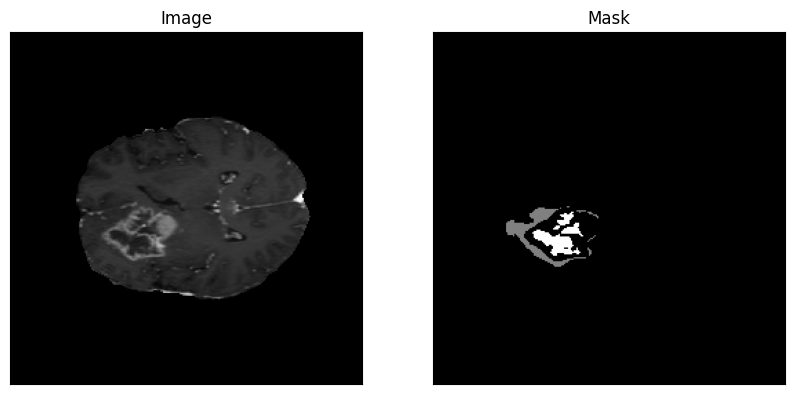

In [239]:
img_num = random.randint(0, padded_images.shape[0]-1)
example_image = dataset[img_num]["image"]
example_mask = dataset[img_num]["label"]

fig, axes = plt.subplots(1, 2, figsize=(10, 10))

# Plot the first image on the left
axes[0].imshow(np.array(example_image), cmap='gray')  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(np.array(example_mask), cmap='gray')  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()

Get bounding boxes from masks. You can get here directly if you are working with coco style annotations where bounding boxes are captured in a JSON file.

In [240]:
#Get bounding boxes from mask.
def get_bounding_box(ground_truth_map):
  # get bounding box from mask
  y_indices, x_indices = np.where(ground_truth_map > 0)
  x_min, x_max = np.min(x_indices), np.max(x_indices)
  y_min, y_max = np.min(y_indices), np.max(y_indices)
  # add perturbation to bounding box coordinates
  H, W = ground_truth_map.shape
  x_min = max(0, x_min - np.random.randint(0, 20))
  x_max = min(W, x_max + np.random.randint(0, 20))
  y_min = max(0, y_min - np.random.randint(0, 20))
  y_max = min(H, y_max + np.random.randint(0, 20))
  bbox = [x_min, y_min, x_max, y_max]

  return bbox

## Creating SAM Dataset

In [241]:
from torch.utils.data import Dataset

class SAMDataset(Dataset):
  """
  This class is used to create a dataset that serves input images and masks.
  It takes a dataset and a processor as input and overrides the __len__ and __getitem__ methods of the Dataset class.
  """
  def __init__(self, dataset, processor):
    self.dataset = dataset
    self.processor = processor

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    item = self.dataset[idx]
    image = item["image"]
    ground_truth_mask = np.array(item["label"])

    # get bounding box prompt
    prompt = get_bounding_box(ground_truth_mask)

    # prepare image and prompt for the model
    inputs = self.processor(image, input_boxes=[[prompt]], return_tensors="pt")

    # remove batch dimension which the processor adds by default
    inputs = {k:v.squeeze(0) for k,v in inputs.items()}

    # add ground truth segmentation
    inputs["ground_truth_mask"] = ground_truth_mask

    return inputs

# Fine-Tuning SAM

In [125]:
%pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 38.1 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 KB 97.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 KB 98.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [242]:
# Initialize the processor
from transformers import SamProcessor
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

In [243]:
# Create an instance of the SAMDataset
train_dataset = SAMDataset(dataset=dataset, processor=processor)
train_dataset

In [244]:
example = train_dataset[0]
for k,v in example.items():
  print(k,v.shape)


pixel_values torch.Size([3, 1024, 1024])
original_sizes torch.Size([2])
reshaped_input_sizes torch.Size([2])
input_boxes torch.Size([1, 4])
ground_truth_mask (256, 256)


In [245]:
# Create a DataLoader instance for the training dataset
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=False)

In [246]:
batch = next(iter(train_dataloader))
for k,v in batch.items():
  print(k,v.shape)

pixel_values torch.Size([2, 3, 1024, 1024])
original_sizes torch.Size([2, 2])
reshaped_input_sizes torch.Size([2, 2])
input_boxes torch.Size([2, 1, 4])
ground_truth_mask torch.Size([2, 256, 256])


In [164]:
batch["ground_truth_mask"].shape

torch.Size([2, 240, 240])

In [247]:
# Load the model
from transformers import SamModel
model = SamModel.from_pretrained("facebook/sam-vit-base")

# make sure we only compute gradients for mask decoder
for name, param in model.named_parameters():
  if name.startswith("vision_encoder") or name.startswith("prompt_encoder"):
    param.requires_grad_(False)

In [248]:
from torch.optim import Adam
import monai
# Initialize the optimizer and the loss function
optimizer = Adam(model.mask_decoder.parameters(), lr=1e-5, weight_decay=0)
#Try DiceFocalLoss, FocalLoss, DiceCELoss
seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

In [250]:
from tqdm import tqdm
from statistics import mean
import torch
from torch.nn.functional import threshold, normalize

#Training loop
num_epochs = 10

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()
for epoch in range(num_epochs):
    epoch_losses = []
    for batch in tqdm(train_dataloader):
      # forward pass
      outputs = model(pixel_values=batch["pixel_values"].to(device),
                      input_boxes=batch["input_boxes"].to(device),
                      multimask_output=False)

      # compute loss
      predicted_masks = outputs.pred_masks.squeeze(1)
      ground_truth_masks = batch["ground_truth_mask"].float().to(device)
      loss = seg_loss(predicted_masks, ground_truth_masks.unsqueeze(1))

      # backward pass (compute gradients of parameters w.r.t. loss)
      optimizer.zero_grad()
      loss.backward()

      # optimize
      optimizer.step()
      epoch_losses.append(loss.item())

    print(f'EPOCH: {epoch}')
    print(f'Mean loss: {mean(epoch_losses)}')

100%|██████████| 23/23 [00:08<00:00,  2.63it/s]


EPOCH: 0
Mean loss: 0.571481818738191


100%|██████████| 23/23 [00:08<00:00,  2.63it/s]


EPOCH: 1
Mean loss: 0.5078147740467734


100%|██████████| 23/23 [00:08<00:00,  2.63it/s]


...

EPOCH: 7
Mean loss: 0.47565753952316614


100%|██████████| 23/23 [00:08<00:00,  2.64it/s]


EPOCH: 8
Mean loss: 0.4865382002747577


100%|██████████| 23/23 [00:08<00:00,  2.64it/s]

EPOCH: 9
Mean loss: 0.4783015549182892


In [251]:
# before freeing space
print(f"Allocated memory :{torch.cuda.memory_allocated()/1e9:.2f}GB")
print(f"Reserved memory :{torch.cuda.memory_reserved()/1e9:.2f}GB")

Allocated memory :0.45GB
Reserved memory :7.42GB


In [252]:
torch.cuda.empty_cache()

In [258]:
# Save the model's state dictionary to a file
torch.save(model.state_dict(), "../models/brats_model_checkpoint_10.pth")

# Inference

In [259]:
from transformers import SamModel, SamConfig, SamProcessor
import torch

In [260]:
# Load the model configuration
model_config = SamConfig.from_pretrained("facebook/sam-vit-base")
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

# Create an instance of the model architecture with the loaded configuration
brats_model = SamModel(config=model_config)
#Update the model by loading the weights from saved file.
brats_model.load_state_dict(torch.load("../models/brats_model_checkpoint_10.pth"))

<All keys matched successfully>

In [261]:
# set the device to cuda if available, otherwise use cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
brats_model.to(device)

SamModel(
  (shared_image_embedding): SamPositionalEmbedding()
  (vision_encoder): SamVisionEncoder(
    (patch_embed): SamPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (layers): ModuleList(
      (0-11): 12 x SamVisionLayer(
        (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): SamVisionAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): SamMLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (neck): SamVisionNeck(
      (conv1): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (layer_norm1): SamLayerNorm()
     

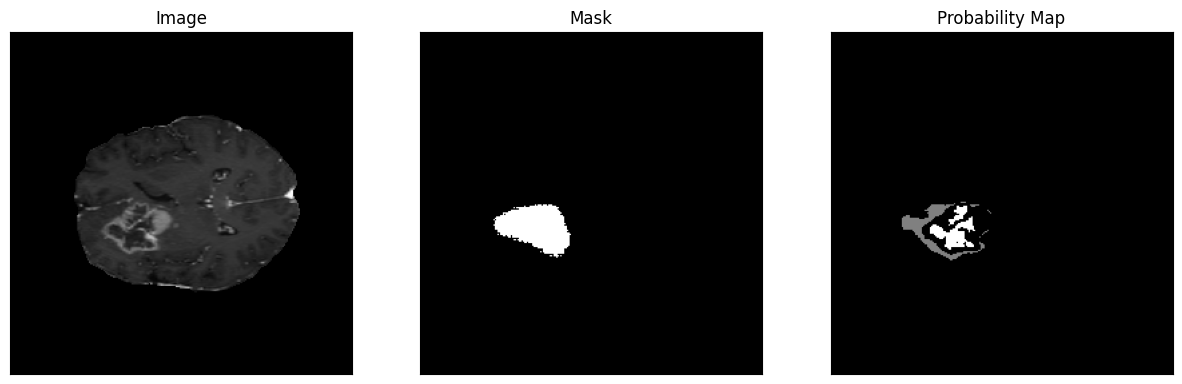

In [292]:
import numpy as np
import random
import torch
import matplotlib.pyplot as plt

# let's take a random training example
idx = random.randint(0, padded_images.shape[0]-1)

# load image
test_image = dataset[idx]["image"]

# get box prompt based on ground truth segmentation map
ground_truth_mask = np.array(dataset[idx]["label"])
prompt = get_bounding_box(ground_truth_mask)

# prepare image + box prompt for the model
inputs = processor(test_image, input_boxes=[[prompt]], return_tensors="pt")

# Move the input tensor to the GPU if it's not already there
inputs = {k: v.to(device) for k, v in inputs.items()}

brats_model.eval()

# forward pass
with torch.no_grad():
    outputs = brats_model(**inputs, multimask_output=False)

# apply sigmoid
medsam_seg_prob = torch.sigmoid(outputs.pred_masks.squeeze(1))
# convert soft mask to hard mask
medsam_seg_prob = medsam_seg_prob.cpu().numpy().squeeze()
medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot the first image on the left
axes[0].imshow(np.array(test_image), cmap='gray')  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(medsam_seg, cmap='gray')  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Plot the second image on the right
axes[2].imshow(np.array(dataset[idx]["label"]),cmap='gray')  # Assuming the second image is grayscale
axes[2].set_title("Probability Map")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()
